[Previous: Module 2: Arrays, Linked Lists, Stacks and Queues](02_Arrays_Linked_Lists_Stacks_Queues.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 4: Recursion, Searching and Sorting](04_Recursion_Searching_and_Sorting.ipynb)

# Module 3: Hash Tables and Sets

**Learning objectives.** After this module you can:

* explain how a hash function turns a key into a bucket index and why that makes lookup O(1) on average;
* implement a hash table with chaining and resizing in a few dozen lines;
* explain collisions and the load factor, and see them in the Hash Table Lab;
* use `dict`, `set` and `Counter` to turn O(n^2) problems into O(n) ones.

**Prerequisites.** [Module 2](02_Arrays_Linked_Lists_Stacks_Queues.ipynb).

## 1. The idea: compute where the key lives

Searching a list for a key means looking at every item. A **hash table** skips the search: it computes a number from the key (the **hash**),
takes it modulo the number of buckets, and goes straight to that bucket. Python's `hash()` does the first step for any immutable object.

The same key always hashes to the same number, so you can find it again. Different keys usually hash to different numbers, but not always: two keys landing in the same bucket
is a **collision**, and handling collisions is most of the design.

In [1]:
import random, time
from collections import Counter
from dsalab import time_it, growth_plot

m = 8
for key in ["apple", "banana", "cherry", 42, (1, 2)]:
    print(f"{str(key):<10} hash = {hash(key):>22}   bucket = hash mod {m} = {hash(key) % m}")
print("\nNote: string hashes change between Python runs on purpose (a security feature). Integer hashes are the integer itself.")

apple      hash =    3917504918507187316   bucket = hash mod 8 = 4
banana     hash =    1885033377230864350   bucket = hash mod 8 = 6
cherry     hash =   -8871966090096136177   bucket = hash mod 8 = 7
42         hash =                     42   bucket = hash mod 8 = 2
(1, 2)     hash =   -3550055125485641917   bucket = hash mod 8 = 3

Note: string hashes change between Python runs on purpose (a security feature). Integer hashes are the integer itself.


## 2. Implement one: chaining and resizing

Each bucket is a small list of `(key, value)` pairs (a **chain**). Lookup hashes to the bucket and scans its chain. Chains stay short as long as the
**load factor** (keys divided by buckets) stays below about 0.75; when it climbs past that, we double the buckets and re-insert everything.
That rehash is O(n), but it happens so rarely that inserts are O(1) amortised, just like `list.append`.

In [2]:
class HashTable:
    def __init__(self, buckets=8):
        self.buckets = [[] for _ in range(buckets)]
        self.count = 0
        self.resizes = 0

    def _bucket(self, key):
        return self.buckets[hash(key) % len(self.buckets)]

    def put(self, key, value):
        bucket = self._bucket(key)
        for i, (k, _v) in enumerate(bucket):
            if k == key:                       # update in place
                bucket[i] = (key, value)
                return
        bucket.append((key, value))
        self.count += 1
        if self.count / len(self.buckets) > 0.75:
            self._resize()

    def get(self, key, default=None):
        for k, v in self._bucket(key):
            if k == key:
                return v
        return default

    def _resize(self):
        old = self.buckets
        self.buckets = [[] for _ in range(2 * len(old))]
        self.count = 0
        self.resizes += 1
        for bucket in old:
            for k, v in bucket:
                self.put(k, v)

    def stats(self):
        chains = [len(b) for b in self.buckets]
        return {"keys": self.count, "buckets": len(self.buckets), "load": round(self.count / len(self.buckets), 2),
                "longest chain": max(chains), "empty buckets": chains.count(0), "resizes": self.resizes}

table = HashTable()
words = "the quick brown fox jumps over the lazy dog and the cat sleeps under the warm sun".split()
for i, w in enumerate(words):
    table.put(w, i)                            # later positions overwrite earlier ones
print("get('the') ->", table.get("the"), "   get('zebra') ->", table.get("zebra"))
print(table.stats())

get('the') -> 14    get('zebra') -> None
{'keys': 14, 'buckets': 32, 'load': 0.44, 'longest chain': 3, 'empty buckets': 23, 'resizes': 2}


> **What to notice.** Fourteen distinct keys, sixteen buckets after one resize, longest chain 2 or 3. Lookup never scans more than a handful of pairs,
> however many keys you add, because resizing keeps the load factor bounded.

### Lab: Hash Table Lab

Random integer keys go into bucket `key mod m`. Push the number of keys up with resizing off and watch chains grow; then switch resizing on.
The interesting quantity is the longest chain, because that is the worst-case lookup.

Hash Table Lab (static preview). Run this cell in JupyterLab for the interactive version.


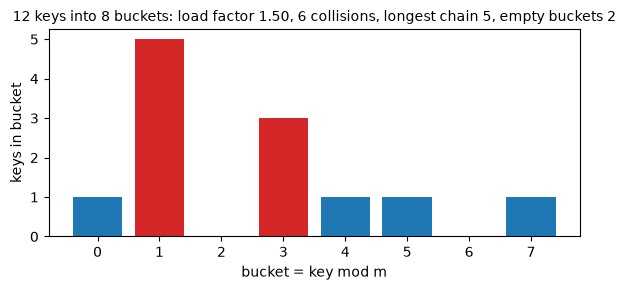

In [3]:
from dsalab import hash_table_lab

hash_table_lab()

## 3. Why `dict` and `set` change everything

Python's `dict` and `set` are hash tables written in C. Membership testing `x in s` is O(1) average for a set and O(n) for a list.
The plot makes the gap visible: two hundred lookups in containers of growing size.

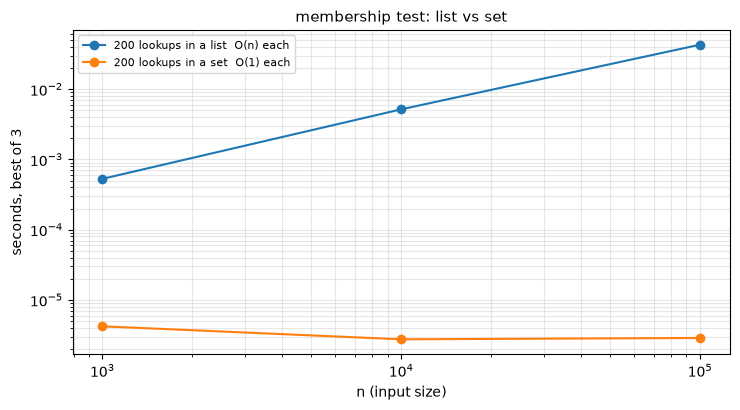

In [4]:
random.seed(3)
sizes = [10**3, 10**4, 10**5]
LISTS = {n: list(range(n)) for n in sizes}
SETS = {n: set(range(n)) for n in sizes}
PROBES = [random.randrange(2 * 10**5) for _ in range(200)]        # half of them are misses

def lookups_list(n):
    container = LISTS[n]
    return sum(1 for x in PROBES if x in container)

def lookups_set(n):
    container = SETS[n]
    return sum(1 for x in PROBES if x in container)

growth_plot({"200 lookups in a list  O(n) each": lookups_list, "200 lookups in a set  O(1) each": lookups_set},
            sizes, title="membership test: list vs set")

In [5]:
# Classic use 1: counting. One pass, O(n).
text = "it was the best of times it was the worst of times it was the age of wisdom".split()
counts = {}
for word in text:
    counts[word] = counts.get(word, 0) + 1
print("by hand:", counts)
print("Counter:", Counter(text).most_common(3))

# Classic use 2: two-sum. Which pair adds up to the target? O(n) with a dict instead of O(n^2) with two loops.
def two_sum(nums, target):
    seen = {}                                   # value -> index
    for i, x in enumerate(nums):
        if target - x in seen:
            return seen[target - x], i
        seen[x] = i
    return None

print("two_sum:", two_sum([2, 7, 11, 15, 1, 8], 9))

by hand: {'it': 3, 'was': 3, 'the': 3, 'best': 1, 'of': 3, 'times': 2, 'worst': 1, 'age': 1, 'wisdom': 1}
Counter: [('it', 3), ('was', 3), ('the', 3)]
two_sum: (0, 1)


## 4. The one rule: keys must be hashable

A key's hash must never change, so keys must be **immutable**: strings, numbers, tuples of immutables, frozensets. A list cannot be a key, because if it changed
after insertion it would hash to a different bucket and be lost. Python refuses up front.

In [6]:
d = {}
d[(1, 2)] = "tuple works"
d["name"] = "string works"
try:
    d[[1, 2]] = "list fails"
except TypeError as e:
    print("TypeError:", e)
print(d)
print("frozenset as a key:", {frozenset({1, 2}): "ok"})

TypeError: unhashable type: 'list'
{(1, 2): 'tuple works', 'name': 'string works'}
frozenset as a key: {frozenset({1, 2}): 'ok'}


## Try it yourself

**Exercise 1.** Group a list of words into anagram groups: `["eat", "tea", "tan", "ate", "nat", "bat"]` should give three groups. Hint: the sorted letters make a good key.

**Exercise 2.** Find the first character in a string that appears exactly once, in O(n).

**Exercise 3.** Add a `delete(key)` method to `HashTable`. Then add `__len__` and `__contains__` so `len(table)` and `key in table` work.

**Exercise 4 (challenge).** Build an LRU cache of capacity k: `get(key)` and `put(key, value)` both O(1), evicting the least recently used key when full. `collections.OrderedDict` with `move_to_end` makes it short.

<details><summary>Solutions</summary>

```python
# Exercise 1
def anagram_groups(words):
    groups = {}
    for w in words:
        groups.setdefault("".join(sorted(w)), []).append(w)
    return list(groups.values())
print(anagram_groups(["eat", "tea", "tan", "ate", "nat", "bat"]))

# Exercise 2
def first_unique(s):
    c = Counter(s)
    return next((ch for ch in s if c[ch] == 1), None)
print(first_unique("swiss"))          # 'w'

# Exercise 3
def delete(self, key):
    bucket = self._bucket(key)
    for i, (k, _v) in enumerate(bucket):
        if k == key:
            del bucket[i]; self.count -= 1; return True
    return False
HashTable.delete = delete
HashTable.__len__ = lambda self: self.count
HashTable.__contains__ = lambda self, key: self.get(key, _MISSING) is not _MISSING
_MISSING = object()

# Exercise 4
from collections import OrderedDict
class LRUCache:
    def __init__(self, capacity): self.cap, self.d = capacity, OrderedDict()
    def get(self, key):
        if key not in self.d: return None
        self.d.move_to_end(key); return self.d[key]
    def put(self, key, value):
        self.d[key] = value; self.d.move_to_end(key)
        if len(self.d) > self.cap: self.d.popitem(last=False)
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [7]:
from dsalab import quiz

quiz(3)

Checkpoint quiz, Module 3 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Average cost of looking up a key in a hash table
    a) O(1)
    b) O(log n)
    c) O(n)
    d) O(n log n)

Q2. A collision happens when
    a) two keys are equal
    b) two different keys land in the same bucket
    c) the table is full
    d) a key is deleted

Q3. Which of these can NOT be a dict key in Python?
    a) a string
    b) an integer
    c) a tuple of integers
    d) a list

Q4. When the load factor grows too high, a hash table
    a) refuses new keys
    b) resizes to more buckets and rehashes every key
    c) switches to a linked list
    d) sorts its keys


## Key takeaways

* A hash table computes the bucket from the key: O(1) average lookup, insert and delete.
* Collisions are normal; chaining handles them, and resizing keeps the load factor (and the chains) small.
* `dict`, `set` and `Counter` are the first thing to reach for when a problem says "have I seen this before?" or "how many of each?".
* Keys must be immutable so their hash never changes.

**Next:** recursion, and the algorithms that split problems in half. [Module 4](04_Recursion_Searching_and_Sorting.ipynb).

[Previous: Module 2: Arrays, Linked Lists, Stacks and Queues](02_Arrays_Linked_Lists_Stacks_Queues.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 4: Recursion, Searching and Sorting](04_Recursion_Searching_and_Sorting.ipynb)